<a href="https://colab.research.google.com/github/omerfarukt61/-la--Kaynakl--Otoimm-nite-Tahmini/blob/main/%C4%B0la%C3%A7_Kaynakl%C4%B1_Otoimm%C3%BCnite_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pd.read_csv('DIA_trainingset_RDKit_descriptors.csv')
test_df  = pd.read_csv('DIA_testset_RDKit_descriptors.csv')

# ilk sütun etiket, ikinci sütun SMILES, geri kalanlar descriptor
y_train = train_df['Label']
y_test  = test_df['Label']

X_train = train_df.drop(columns=['Label', 'SMILES'])
X_test  = test_df.drop(columns=['Label', 'SMILES'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"egitim: {X_train.shape[0]} ornek, {X_train.shape[1]} ozellik")
print(f"test  : {X_test.shape[0]} ornek")

egitim: 477 ornek, 196 ozellik
test  : 120 ornek


In [3]:
print("=== 1. K-Means ===")

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_clusters = kmeans.fit_predict(X_test_scaled)

acc_kmeans = accuracy_score(y_test, kmeans_clusters)

# k-means rastgele etiket atadigi icin gerekirse terse ceviriyoruz
if acc_kmeans < 0.5:
    kmeans_clusters = 1 - kmeans_clusters
    acc_kmeans = accuracy_score(y_test, kmeans_clusters)

print(f"benzerlik orani: %{acc_kmeans*100:.2f}")
print(classification_report(y_test, kmeans_clusters))

=== 1. K-Means ===
benzerlik orani: %62.50
              precision    recall  f1-score   support

           0       0.76      0.72      0.74        90
           1       0.29      0.33      0.31        30

    accuracy                           0.62       120
   macro avg       0.53      0.53      0.53       120
weighted avg       0.64      0.62      0.63       120



In [4]:
print("=== 2. Lineer Regresyon ===")

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_cont = lin_reg.predict(X_test_scaled)
y_pred_lin  = (y_pred_cont >= 0.5).astype(int)

print(f"dogruluk: %{accuracy_score(y_test, y_pred_lin)*100:.2f}")
print(classification_report(y_test, y_pred_lin))

=== 2. Lineer Regresyon ===
dogruluk: %80.83
              precision    recall  f1-score   support

           0       0.86      0.89      0.87        90
           1       0.63      0.57      0.60        30

    accuracy                           0.81       120
   macro avg       0.74      0.73      0.74       120
weighted avg       0.80      0.81      0.80       120



In [5]:
print("=== 3. Naive Bayes ===")

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)

print(f"dogruluk: %{accuracy_score(y_test, y_pred_nb)*100:.2f}")
print(classification_report(y_test, y_pred_nb))

=== 3. Naive Bayes ===
dogruluk: %36.67
              precision    recall  f1-score   support

           0       0.75      0.23      0.36        90
           1       0.25      0.77      0.38        30

    accuracy                           0.37       120
   macro avg       0.50      0.50      0.37       120
weighted avg       0.62      0.37      0.36       120



In [6]:
print("=== 4. KNN ===")

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

print(f"dogruluk: %{accuracy_score(y_test, y_pred_knn)*100:.2f}")
print(classification_report(y_test, y_pred_knn))

=== 4. KNN ===
dogruluk: %85.00
              precision    recall  f1-score   support

           0       0.86      0.96      0.91        90
           1       0.80      0.53      0.64        30

    accuracy                           0.85       120
   macro avg       0.83      0.74      0.77       120
weighted avg       0.85      0.85      0.84       120



In [7]:
print("=== 5. SVM ===")

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print(f"dogruluk: %{accuracy_score(y_test, y_pred_svm)*100:.2f}")
print(classification_report(y_test, y_pred_svm))

=== 5. SVM ===
dogruluk: %80.00
              precision    recall  f1-score   support

           0       0.81      0.97      0.88        90
           1       0.75      0.30      0.43        30

    accuracy                           0.80       120
   macro avg       0.78      0.63      0.65       120
weighted avg       0.79      0.80      0.77       120



In [8]:
print("=== 6. Karar Agaci ===")

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print(f"dogruluk: %{accuracy_score(y_test, y_pred_dt)*100:.2f}")
print(classification_report(y_test, y_pred_dt))

=== 6. Karar Agaci ===
dogruluk: %72.50
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        90
           1       0.44      0.40      0.42        30

    accuracy                           0.72       120
   macro avg       0.63      0.62      0.62       120
weighted avg       0.72      0.72      0.72       120



In [9]:
print("=== 7. Random Forest ===")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print(f"dogruluk: %{accuracy_score(y_test, y_pred_rf)*100:.2f}")
print(classification_report(y_test, y_pred_rf))

=== 7. Random Forest ===
dogruluk: %78.33
              precision    recall  f1-score   support

           0       0.79      0.97      0.87        90
           1       0.70      0.23      0.35        30

    accuracy                           0.78       120
   macro avg       0.75      0.60      0.61       120
weighted avg       0.77      0.78      0.74       120



In [10]:
print("=== 8. YSA (MLP) ===")

# 2 gizli katman denedim, 100-50 iyi sonuc verdi
ysa_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
ysa_model.fit(X_train_scaled, y_train)
y_pred_ysa = ysa_model.predict(X_test_scaled)

print(f"dogruluk: %{accuracy_score(y_test, y_pred_ysa)*100:.2f}")
print(classification_report(y_test, y_pred_ysa))

=== 8. YSA (MLP) ===
dogruluk: %80.83
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        90
           1       0.71      0.40      0.51        30

    accuracy                           0.81       120
   macro avg       0.77      0.67      0.70       120
weighted avg       0.80      0.81      0.79       120



In [11]:
print("=== 9. CNN ===")

# Conv1D icin (ornek, ozellik, kanal) formatina getiriyoruz
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn  = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_cnn, y_train, epochs=20, batch_size=32, verbose=0)

y_pred_cnn_prob = cnn_model.predict(X_test_cnn, verbose=0)
y_pred_cnn = (y_pred_cnn_prob > 0.5).astype(int).flatten()

print(f"dogruluk: %{accuracy_score(y_test, y_pred_cnn)*100:.2f}")
print(classification_report(y_test, y_pred_cnn))

=== 9. CNN ===
dogruluk: %80.00
              precision    recall  f1-score   support

           0       0.83      0.92      0.87        90
           1       0.65      0.43      0.52        30

    accuracy                           0.80       120
   macro avg       0.74      0.68      0.70       120
weighted avg       0.79      0.80      0.79       120



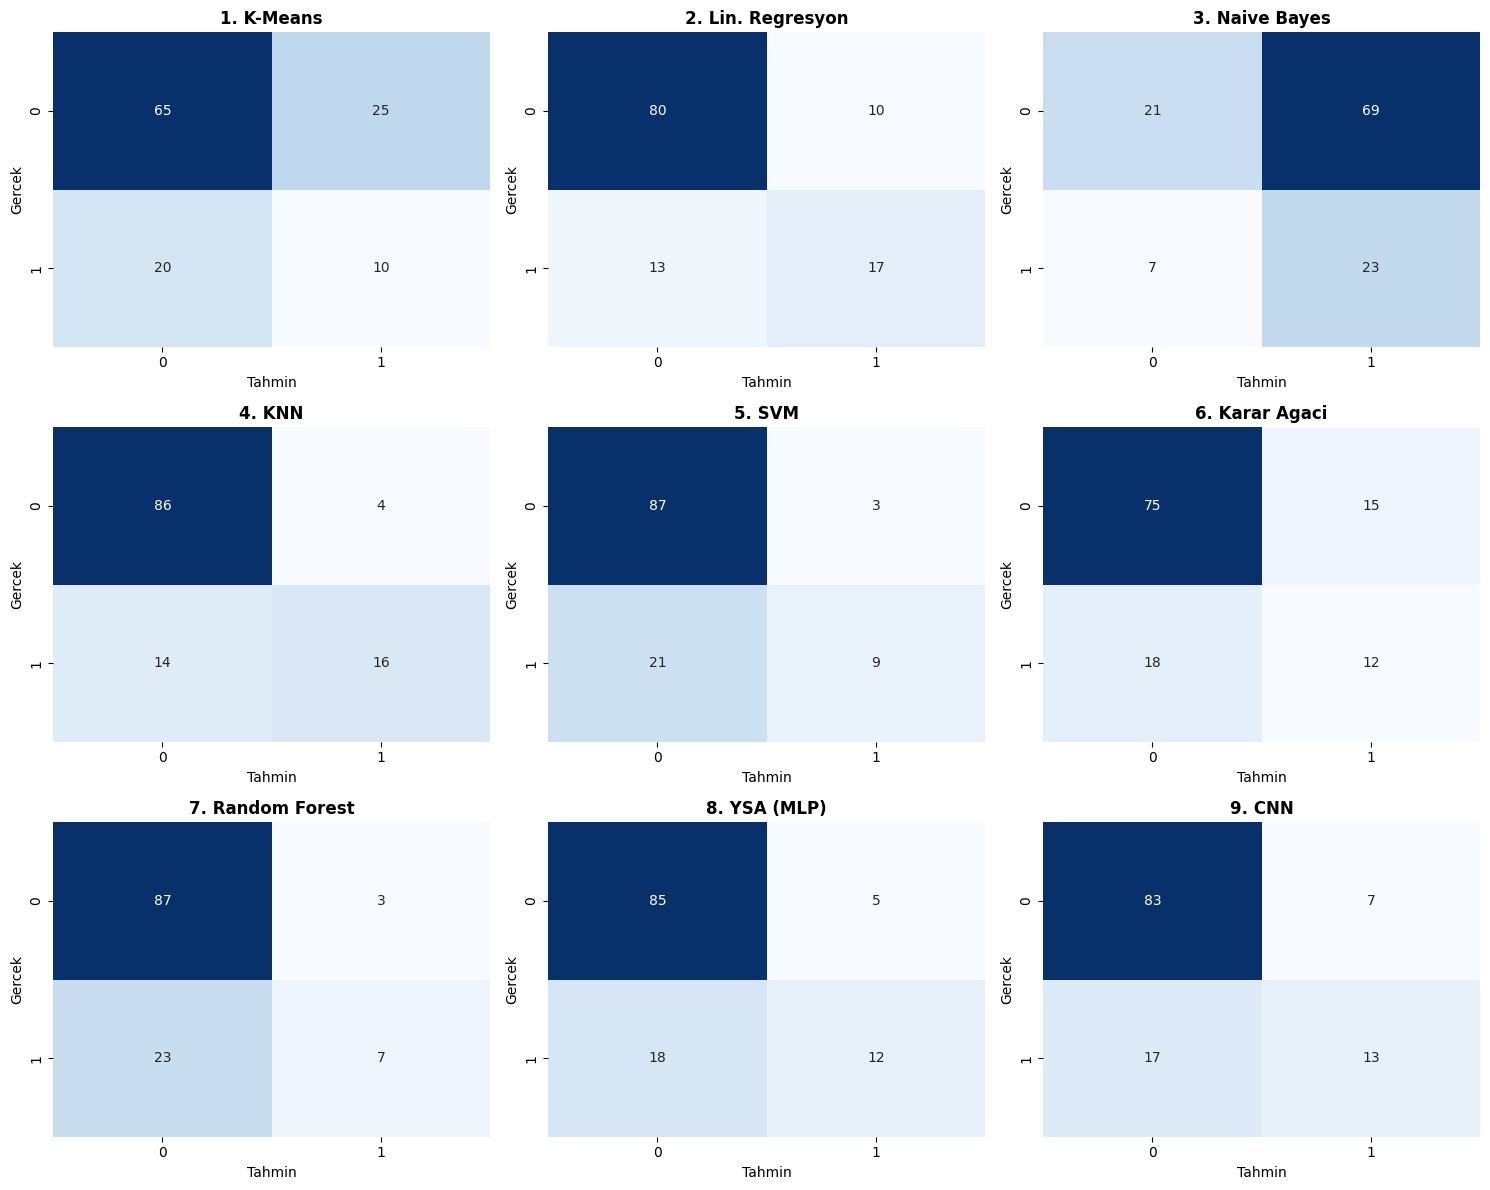

In [12]:
tahminler = {
    "1. K-Means"        : kmeans_clusters,
    "2. Lin. Regresyon" : y_pred_lin,
    "3. Naive Bayes"    : y_pred_nb,
    "4. KNN"            : y_pred_knn,
    "5. SVM"            : y_pred_svm,
    "6. Karar Agaci"    : y_pred_dt,
    "7. Random Forest"  : y_pred_rf,
    "8. YSA (MLP)"      : y_pred_ysa,
    "9. CNN"            : y_pred_cnn,
}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, (isim, y_pred) in zip(axes.flatten(), tahminler.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(isim, fontsize=12, fontweight='bold')
    ax.set_xlabel("Tahmin")
    ax.set_ylabel("Gercek")

plt.tight_layout()
plt.show()